# Access a NetCDF file from Zenodo

This notebook shows an example how to access a NetCDF published on the [https://zenodo.org](https://zenodo.org) webpage. 

### Setup
In order to run this notebook, you need to install [`xcube_zenodo`](https://github.com/xcube-dev/xcube-zenodo), following the [README](../README.md).

Note that [`xcube_zenodo`](https://github.com/xcube-dev/xcube-zenodo) is a plugin of [`xcube`](https://xcube.readthedocs.io/en/latest/), where `xcube` is included in the `environment.yml`.  

Now, we first import everything we need:

In [1]:
%%time
from xcube.core.store import new_data_store

CPU times: user 4.22 s, sys: 491 ms, total: 4.71 s
Wall time: 3.83 s


We initialize a new data store using the corresponding record ID, which can be found in the URL of the record: https://zenodo.org/records/13882297.

In [2]:
%%time
store = new_data_store("zenodo", root="13882297")

CPU times: user 79.8 ms, sys: 22.9 ms, total: 103 ms
Wall time: 102 ms


We can list all available data IDs again executing the following cell.

In [3]:
%%time
store.list_data_ids()

CPU times: user 75.1 ms, sys: 12.1 ms, total: 87.3 ms
Wall time: 1.19 s


['gridded_constituents_tideonly.nc',
 'gridded_constituents_ERA5weather.nc',
 'gridded_tidestats_ERA5weather.nc',
 'gridded_tidestats_tideonly.nc']

NetCDF files can be preloaded using the `preload_data` method. This approach enables the downloading of NetCDF files that cannot be lazily loaded, allowing them to be stored and readily available for the duration of the project. Also this method uses `preload_params`, which can be viewed in the next cell.

In [4]:
%%time
preload_params = store.get_preload_data_params_schema()
preload_params

CPU times: user 70 μs, sys: 10 μs, total: 80 μs
Wall time: 83.9 μs


The `preload_data` method returns a store which may be used subsequently to access the preloaded data, as shown in the subsequent cells. If no data IDs are given, all available data in compressed format will be preloaded. Note that the `preload_method` is new and highly experimental.

In [5]:
%%time
cache_store = store.preload_data("gridded_tidestats_ERA5weather.nc")

/home/konstantin/bc_kon/01_coding/01_github/xcube-zenodo/examples/zenodo_temp/zenodo_cache/13882297


Data ID,Status,Progress,Message,Exception
gridded_tidestats_ERA5weather.nc,COMPLETED,100%,Preload finished,-


/home/konstantin/bc_kon/01_coding/01_github/xcube-zenodo/examples/zenodo_temp/zenodo_cache/13882297
CPU times: user 295 ms, sys: 291 ms, total: 587 ms
Wall time: 14.6 s


The data IDs can be view by listing the data IDs of the cache store, which is returned by the `preload_data` method.

In [6]:
cache_store.list_data_ids()

['gridded_tidestats_ERA5weather.nc']

In [7]:
ds = cache_store.open_data("gridded_tidestats_ERA5weather.nc")
ds

<xarray.Dataset> Size: 15MB
Dimensions:  (y: 375, x: 297)
Dimensions without coordinates: y, x
Data variables: (12/17)
    nav_lon  (y, x) float64 891kB ...
    nav_lat  (y, x) float64 891kB ...
    z0       (y, x) float64 891kB ...
    HAT      (y, x) float64 891kB ...
    LAT      (y, x) float64 891kB ...
    MHW      (y, x) float64 891kB ...
    ...       ...
    MHHW     (y, x) float64 891kB ...
    MLLW     (y, x) float64 891kB ...
    RangeAT  (y, x) float64 891kB ...
    MSRange  (y, x) float64 891kB ...
    MRange   (y, x) float64 891kB ...
    MNRange  (y, x) float64 891kB ...
Attributes:
    Author:       Joanne Williams, joll@noc.ac.uk
    Institute:    National Oceanography Centre
    Title:        Tidal constituents for NOCtide from model run
    Modelrun:     ERA5weather
    Modelconfig:  newfriction
    TimeStamp:    11-Jun-2024 13:01:44
    Notes:        Statistics based on ERA5 hindcast run from 1980 to 2022. \n...

We can also use the cache store to access the preloaded data. 

We plot the Mean Low Water (MLW) data as an example. 

CPU times: user 521 ms, sys: 53.5 ms, total: 575 ms
Wall time: 575 ms


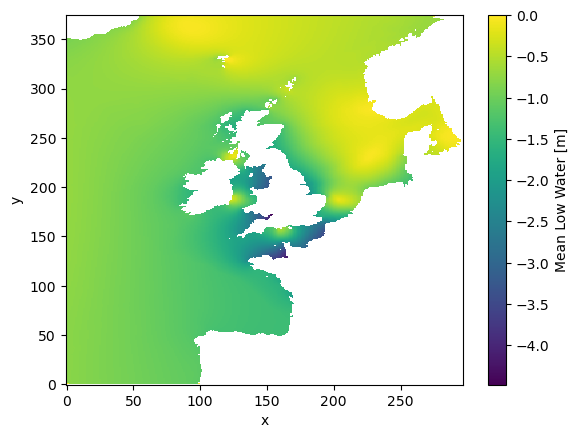

In [8]:
%%time
ds.MLW.plot()